In [ ]:
from models import VGG11_224, VDP_VGG11_224
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
import torch.nn as nn
from utils import mc_nll
import time

device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

In [2]:
import torchvision.transforms as transforms
import torchvision.datasets as datasets
# Train on food, validate on flowers

trans = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_ds = datasets.Food101(root="/home/jw7630/repos/sparsity/data", split="train", transform=trans, download=True)
test_ds = datasets.Food101(root="/home/jw7630/repos/sparsity/data", split="test", transform=trans, download=True)
ood_ds = datasets.Flowers102(root="/home/jw7630/repos/sparsity/data", split="test", transform=trans, download=True)
batch_size=64
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=batch_size, shuffle=False)
ood_loader = torch.utils.data.DataLoader(ood_ds, batch_size=batch_size, shuffle=False)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.23921573].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.9529412].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8352941..0.9529412].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8901961..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8901961].
Clipping input dat

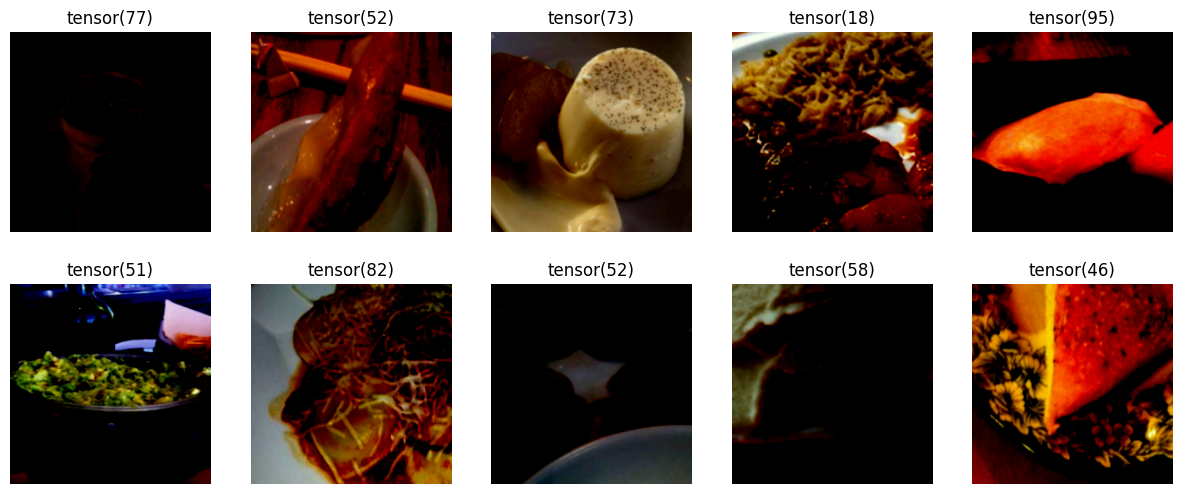

In [ ]:
images, labels = next(iter(train_loader))
images = images[:10]
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flatten()):
    img = images[i].cpu().numpy()  # Convert the image to numpy for plotting
    ax.imshow(np.transpose(img, (1, 2, 0)))  # Convert CHW to HWC format
    ax.axis('off')  # Hide axes
    ax.set_title(labels[i])

plt.show()

# Train the models

In [4]:
# train deterministic VGG on FOOD101
model = VGG11_224(num_classes=101).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

start_time = time.time()
for epoch in range(101):
    model.train()
    correct = 0
    running_loss = 0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            running_loss = loss.item()
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            
    if epoch+1 % 10 == 0:
        # evaluate on test set
        model.eval()
        test_loss = 0
        correct = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                test_loss += criterion(outputs, labels).item()
                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == labels).sum().item()
        print(f"Epoch [{epoch+1}/10], Test loss: {loss.item():.4f}, Test Acc: {100 * correct / len(test_loader.dataset):.2f}%")
        current_time = time.time()
        print(f"Epoch [{epoch+1}/10], Train loss: {running_loss:.4f}, Acc: {100 * correct / len(train_loader.dataset):.2f}%")
        print(f"Finished 10 epochs in {(current_time - start_time)/60:.2f} minutes")
        start_time = current_time

KeyboardInterrupt: 

In [6]:
import torchvision
m2 = torchvision.models.vgg11()

In [ ]:
# Load weights of deterministic VGG into VDP_VGG
model = VGG11_224(num_classes=101, bias=False).to(device)  
model_vdp = VDP_VGG11_224(num_classes=101).to(device)
model_vdp(torch.randn(1, 3, 224, 224), training=True)
model_vdp.load_weights(model)

In [ ]:
# Further train sigma
EPOCHS = 100
kl_factor = 0.0005
model_vdp.train()
optimizer = optim.Adam(model_vdp.parameters(), lr=0.001)
model_vdp = model_vdp.to(device)
for epoch in range(EPOCHS):
    # TRAINING
    running_loss, running_kl, accuracy, average_sigma = 0.0, 0.0, 0.0, 0.0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        mu, sigma, kl = model_vdp(images)
        loss1 = mc_nll(labels, mu, sigma)
        loss = loss1 + kl_factor * kl
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_kl += kl.item()
        accuracy += (mu.argmax(dim=1) == labels).float().sum().item()
        average_sigma += sigma.mean(1).sum().item()
    running_loss /= len(train_loader.dataset)
    running_kl /= len(train_loader.dataset)
    accuracy /= len(train_loader.dataset.dataset)
    average_sigma /= len(train_loader.dataset)
   
   # EVALUATION
    test_loss, test_kl, test_accuracy, test_average_sigma = 0.0, 0.0, 0.0, 0.0
    for test_images, test_labels in test_loader:
        test_images = test_images.to(device)
        test_labels = test_labels.to(device)
        test_outputs, test_sigmas, kl = model_vdp(test_images)
        test_loss += mc_nll(test_labels.cpu(), test_outputs.cpu(), test_sigmas.cpu()).item()
        test_accuracy += (test_outputs.cpu().argmax(dim=1) == test_labels.cpu()).float().sum().cpu().item()
        test_average_sigma += test_sigmas.mean(1).sum().cpu().item()
        test_kl += kl.cpu().item()

        del test_images, test_labels, test_outputs, test_sigmas, kl
        torch.cuda.empty_cache()
        optimizer.zero_grad()

    test_loss /= len(test_loader.dataset)
    test_kl /= len(test_loader.dataset)
    test_accuracy /= len(test_loader.dataset)
    test_average_sigma /= len(test_loader.dataset)
    print(f'Epoch [{epoch+1}/{EPOCHS}], Test Loss: {test_loss:.4f}, kl {test_kl:.4f}Test Accuracy: {test_accuracy:.4f}')
    print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss:.4f}, kl {running_kl:.4f}Accuracy: {accuracy:.4f}')

torch.save(model.state_dict(), 'vggm11_vdp.pth')

Epoch [1/50], Test Loss: 4.8687, kl 114.0651Test Accuracy: 0.0099
Epoch [1/50], Loss: 6.1334, kl 168.6121Accuracy: 0.0098
Epoch [11/50], Test Loss: 4.0864, kl 220.4940Test Accuracy: 0.1084
Epoch [11/50], Loss: 4.2948, kl 212.8145Accuracy: 0.0965


In [ ]:
EPOCHS = 50
model.train()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    running_loss, accuracy = 0.0, 0.0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        accuracy += (outputs.argmax(dim=1) == labels).float().sum()
    running_loss /= len(train_loader)
    accuracy /= len(train_loader.dataset)

    if epoch % 10 == 0:
        test_loss, test_accuracy = 0.0, 0.0
        for test_images, test_labels in test_loader:
            test_images = test_images.to(device)
            test_labels = test_labels.to(device)
            test_outputs = model(test_images)
            test_loss += criterion(test_outputs, test_labels).item()
            test_accuracy += (test_outputs.argmax(dim=1) == test_labels).float().sum()
        test_loss /= len(test_loader)
        test_accuracy /= len(test_loader.dataset)
        print(f'Epoch [{epoch+1}/{EPOCHS}], Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')
        print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss:.4f}, Accuracy: {accuracy:.4f}')

torch.save(model.state_dict(), 'vggm11.pth')

Epoch [1/50], Test Loss: 4.6200, Test Accuracy: 0.0099
Epoch [1/50], Loss: 5.4821, Accuracy: 0.0091
Epoch [11/50], Test Loss: 3.7887, Test Accuracy: 0.1217
Epoch [11/50], Loss: 3.9158, Accuracy: 0.1086
Epoch [21/50], Test Loss: 3.2340, Test Accuracy: 0.2285
Epoch [21/50], Loss: 3.2984, Accuracy: 0.2174
Epoch [31/50], Test Loss: 2.8617, Test Accuracy: 0.3093
Epoch [31/50], Loss: 2.8548, Accuracy: 0.3067
Epoch [41/50], Test Loss: 2.6576, Test Accuracy: 0.3572
Epoch [41/50], Loss: 2.5555, Accuracy: 0.3716


In [22]:
test_loss, test_accuracy = 0.0, 0.0
for test_images, test_labels in test_loader:
    test_images = test_images.to(device)
    test_labels = test_labels.to(device)
    test_outputs = model(test_images)
    test_loss += criterion(test_outputs, test_labels).item()
    test_accuracy += (test_outputs.argmax(dim=1) == test_labels).float().sum()
test_loss /= len(test_loader)
test_accuracy /= len(test_loader.dataset)
print(f'Epoch [{epoch+1}/{EPOCHS}], Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')
print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss:.4f}, Accuracy: {accuracy:.4f}')

Epoch [50/50], Test Loss: 2.6198, Test Accuracy: 0.3671
Epoch [50/50], Loss: 2.3624, Accuracy: 0.4130


# Probabilistic finetuning

In [ ]:
from evaluate_models import compare_two_models
from copy import deepcopy
from utils_vdp import dirichlet_loss

model_vdp = VDP_VGG11_224(num_classes=1000).to(device)
model_vdp(next(iter(train_loader))[0])
model = VGG11_224(num_classes=1000, bias=False)
model.load_state_dict(torch.load('vggm11-50.pth'))
model_vdp.load_weights(model)
model_vdp_finetune = deepcopy(model_vdp)



# Experiment 1: 
# Train ONLY sigma with 3 different loss functions: Gaussian, Dirichlet and MC



# Experiment 2:
# Train mu and sigma with 3 different loss functions: Gaussian, Dirichlet and MC




Parameters assigned successfully.


In [4]:
EPOCHS = 5
kl_factor = 0.001
model_vdp_finetune.train()
optimizer = optim.Adam(list(model_vdp_finetune.parameters())[::2], lr=0.01)
model_vdp_finetune = model_vdp_finetune.to(device)


for epoch in range(EPOCHS):
    print(epoch)
    running_loss, running_kl, accuracy = 0.0, 0.0, 0.0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        mu, sigma, kl = model_vdp_finetune(images)
        loss1 = dirichlet_loss(mu, sigma, labels)
        loss = loss1 + kl_factor * kl
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_kl += kl.item()
        accuracy += (mu.argmax(dim=1) == labels).float().sum()
    running_loss /= len(train_loader)
    running_kl /= len(train_loader)
    accuracy /= len(train_loader.dataset)
    print(running_loss)
    # if epoch % 10 == 0:
    #     test_loss, test_kl, test_accuracy = 0.0, 0.0, 00
    #     for test_images, test_labels in test_loader:
    #         test_images = test_images.to(device)
    #         test_labels = test_labels.to(device)
    #         test_outputs, test_sigmas, kl = model_vdp_finetune(test_images)
    #         test_loss += dirichlet_loss(test_outputs, test_sigmas, test_labels).item()
    #         test_accuracy += (test_outputs.argmax(dim=1) == test_labels).float().sum()
    #         test_kl += kl.item()
    #     test_loss /= len(test_loader)
    #     test_kl /= len(test_loader)
    #     test_accuracy /= len(test_loader.dataset)
    #     print(f'Epoch [{epoch+1}/{EPOCHS}], Test Loss: {test_loss:.4f}, kl {test_kl:.4f}, Test Accuracy: {test_accuracy:.4f}')
    #     print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss:.4f}, kl {running_kl:.4f}, Accuracy: {accuracy:.4f}')

torch.save(model_vdp_finetune.state_dict(), 'vggm11_vdp_50_finetuned_dirichlet.pth')

0
7.4698613825682045
1
6.97570828771269
2
6.975749143474811
3
6.9759033354553015
4
6.975804397785986


In [ ]:
model_vdp = VDP_VGG11_224(num_classes=1000).to(device)
model_vdp(next(iter(train_loader))[0])
model_vdp.load_state_dict(torch.load('vggm11_vdp_50_finetuned_dirichlet.pth'))

model = VGG11_224(num_classes=1000, bias=False)
model.load_state_dict(torch.load('vggm11-50.pth'))


<All keys matched successfully>

In [3]:
from torch.utils.data import  Subset, DataLoader
test = DataLoader(Subset(test_loader.dataset, torch.randperm(len(test_loader.dataset))[:1000]), batch_size=25)
ood = DataLoader(Subset(ood_loader.dataset, torch.randperm(len(ood_loader.dataset))[:1000]), batch_size=25)

In [6]:
from evaluate_models import compare_two_models
from copy import deepcopy
from utils import dirichlet_loss
r = compare_two_models(model, model_vdp, test, ood, device)

Evaluating models
Evaluating VDP model
Evaluating calibration
Evaluating Gaussian noise
{'max_output_auroc': np.float64(0.636306), 'max_output_aupr': np.float64(0.6554885341997466), 'max_output_fpr95': np.float64(0.912), 'entropy_auroc': np.float64(0.576943), 'entropy_aupr': np.float64(0.6000382833663344), 'entropy_fpr95': np.float64(0.933)} {'max_output_auroc': np.float64(0.5), 'max_output_aupr': np.float64(0.75), 'max_output_fpr95': np.float64(1.0), 'mean_output_sigma_auroc': np.float64(0.5), 'mean_output_sigma_aupr': np.float64(0.75), 'mean_output_sigma_fpr95': np.float64(1.0), 'max_output_sigma_auroc': np.float64(0.5), 'max_output_sigma_aupr': np.float64(0.75), 'max_output_sigma_fpr95': np.float64(1.0), 'entropy_auroc': np.float64(0.5), 'entropy_aupr': np.float64(0.75), 'entropy_fpr95': np.float64(1.0), 'mean_logits_sigma_auroc': np.float64(0.510024), 'mean_logits_sigma_aupr': np.float64(0.480205187227575), 'mean_logits_sigma_fpr95': np.float64(0.983), 'max_logits_sigma_auroc': np.

In [9]:
model = VGG11_224(num_classes=1000, bias=False)
model.load_state_dict(torch.load('vggm11-50.pth'))

model_vdp_raw = VDP_VGG11_224(num_classes=1000).to(device)
model_vdp_raw(next(iter(train_loader))[0])
model_vdp_raw.load_weights(model)


RuntimeError: Error(s) in loading state_dict for VGG11_224:
	Missing key(s) in state_dict: "fc1.weight", "fc2.weight", "fc3.weight". 
	Unexpected key(s) in state_dict: "classifier.0.weight", "classifier.2.weight", "classifier.4.weight". 

In [33]:
print(list(model.parameters())[0])


Parameter containing:
tensor([[[[-0.2199,  0.0730,  0.0414],
          [ 0.0139,  0.0746, -0.1353],
          [-0.0563, -0.0840, -0.1752]],

         [[-0.0484,  0.0754, -0.1300],
          [ 0.0153, -0.0803,  0.1673],
          [ 0.1917, -0.0347,  0.1433]],

         [[ 0.0990,  0.1821, -0.0959],
          [ 0.0856, -0.1309, -0.0533],
          [ 0.0177,  0.1352,  0.0163]]],


        [[[-0.2451, -0.0124, -0.0574],
          [ 0.0910, -0.0313,  0.1887],
          [-0.2011,  0.1225,  0.2257]],

         [[-0.1404,  0.0178, -0.1300],
          [-0.0142, -0.1170,  0.1881],
          [-0.1256,  0.1062,  0.1862]],

         [[-0.0617,  0.0499, -0.1410],
          [ 0.1423, -0.0815,  0.0180],
          [-0.0240,  0.1504, -0.1143]]],


        [[[-0.2094,  0.0640,  0.1564],
          [ 0.0991, -0.1344, -0.0471],
          [ 0.0025, -0.0580, -0.1052]],

         [[-0.0428, -0.0408, -0.0810],
          [-0.0132, -0.0305,  0.0942],
          [ 0.1492, -0.1396,  0.1403]],

         [[ 0.2041,  0

In [35]:
print(list(model_vdp.parameters())[0])

Parameter containing:
tensor([[[[-0.2199,  0.0730,  0.0414],
          [ 0.0139,  0.0746, -0.1353],
          [-0.0563, -0.0840, -0.1752]],

         [[-0.0484,  0.0754, -0.1300],
          [ 0.0153, -0.0803,  0.1673],
          [ 0.1917, -0.0347,  0.1433]],

         [[ 0.0990,  0.1821, -0.0959],
          [ 0.0856, -0.1309, -0.0533],
          [ 0.0177,  0.1352,  0.0163]]],


        [[[-0.2451, -0.0124, -0.0574],
          [ 0.0910, -0.0313,  0.1887],
          [-0.2011,  0.1225,  0.2257]],

         [[-0.1404,  0.0178, -0.1300],
          [-0.0142, -0.1170,  0.1881],
          [-0.1256,  0.1062,  0.1862]],

         [[-0.0617,  0.0499, -0.1410],
          [ 0.1423, -0.0815,  0.0180],
          [-0.0240,  0.1504, -0.1143]]],


        [[[-0.2094,  0.0640,  0.1564],
          [ 0.0991, -0.1344, -0.0471],
          [ 0.0025, -0.0580, -0.1052]],

         [[-0.0428, -0.0408, -0.0810],
          [-0.0132, -0.0305,  0.0942],
          [ 0.1492, -0.1396,  0.1403]],

         [[ 0.2041,  0

In [12]:
compare_two_models(model, model_vdp, test, ood, device)

Evaluating models
Evaluating VDP model
Evaluating calibration
Evaluating Gaussian noise
{'max_output_auroc': np.float64(0.652846), 'max_output_aupr': np.float64(0.6715462462117235), 'max_output_fpr95': np.float64(0.896), 'entropy_auroc': np.float64(0.584354), 'entropy_aupr': np.float64(0.6049219964153035), 'entropy_fpr95': np.float64(0.919)} {'max_output_auroc': np.float64(0.549697), 'max_output_aupr': np.float64(0.5074230205822234), 'max_output_fpr95': np.float64(0.881), 'mean_output_sigma_auroc': np.float64(0.5), 'mean_output_sigma_aupr': np.float64(0.75), 'mean_output_sigma_fpr95': np.float64(1.0), 'max_output_sigma_auroc': np.float64(0.5520769999999999), 'max_output_sigma_aupr': np.float64(0.5627902804028869), 'max_output_sigma_fpr95': np.float64(0.89), 'entropy_auroc': np.float64(0.501895), 'entropy_aupr': np.float64(0.47879450753666336), 'entropy_fpr95': np.float64(0.924), 'mean_logits_sigma_auroc': np.float64(0.5568185), 'mean_logits_sigma_aupr': np.float64(0.5352115931245165), 

In [24]:
iii2 = 0
model = model.to(device)
for x,y in test:
    x = x.to(device)
    y = y.to(device)
    mu = model(x)
    iii2+=(mu.argmax(1) == y).sum().item()

In [16]:
iii, jjj, kkk  = 0, 0, 0
model_vdp = model_vdp.to(device)
model_vdp_raw = model_vdp_raw.to(device)
model = model.to(device)
for x,y in test:
    x = x.to(device)
    y = y.to(device)
    mu, sigma, kl = model_vdp(x)
    mu_raw, _, _ = model_vdp_raw(x)
    mu_det = model(x)

    iii+=(mu.argmax(1) == y).sum().item()
    jjj+=(mu_raw.argmax(1) == y).sum().item()
    kkk+=(mu_det.argmax(1) == y).sum().item()

KeyboardInterrupt: 

In [4]:
m1 = VDP_VGG11_224()
m1(next(iter(test))[0])
m2 = VGG11_224(bias=False)
m1.load_weights(m2)

Parameters assigned successfully.


In [5]:
inn = torch.ones(100,3,224,224)
mu_out5, sigma_out, kl, muuu, mu1, mu2, mu3, mu4, mu_out5 = m1(inn)
xx, x1, x2, x3, x4, x5 = m2(inn)

In [8]:
(mu_out5 == x5).all()

tensor(True)

In [20]:
mu3.max()

tensor(0.0011, grad_fn=<MaxBackward1>)

In [27]:
x3.shape

torch.Size([100, 4096])

In [ ]:
mu3.shape

torch.Size([100, 4096])

In [22]:
(mu3 - x3)

tensor([[-0.0001,  0.0001,  0.0002,  ...,  0.0003, -0.0006, -0.0010],
        [-0.0001,  0.0001,  0.0002,  ...,  0.0003, -0.0006, -0.0010],
        [-0.0001,  0.0001,  0.0002,  ...,  0.0003, -0.0006, -0.0010],
        ...,
        [-0.0001,  0.0001,  0.0002,  ...,  0.0003, -0.0006, -0.0010],
        [-0.0001,  0.0001,  0.0002,  ...,  0.0003, -0.0006, -0.0010],
        [-0.0001,  0.0001,  0.0002,  ...,  0.0003, -0.0006, -0.0010]],
       grad_fn=<SubBackward0>)

In [34]:
list(m2.named_parameters())[-2].shape

AttributeError: 'tuple' object has no attribute 'shape'

In [33]:
list(m1.named_parameters())[-4][1].shape

torch.Size([4096, 4096])

In [46]:
(torch.matmul(xx, list(m2.named_parameters())[-3][1].t()) == mu1).all()

tensor(True)

In [40]:
list(m2.named_parameters())[-1][1].t()



tensor([[-0.0050,  0.0106,  0.0066,  ...,  0.0155, -0.0024,  0.0140],
        [ 0.0104, -0.0122, -0.0083,  ..., -0.0125,  0.0146, -0.0086],
        [-0.0113, -0.0154,  0.0102,  ...,  0.0027, -0.0038,  0.0057],
        ...,
        [-0.0075, -0.0091, -0.0051,  ...,  0.0048,  0.0074, -0.0093],
        [ 0.0030,  0.0062,  0.0063,  ..., -0.0066, -0.0069,  0.0153],
        [ 0.0003, -0.0116,  0.0075,  ...,  0.0140, -0.0020,  0.0076]],
       grad_fn=<TBackward0>)

In [27]:
list(m2.named_parameters())[-1]


('fc3.weight',
 Parameter containing:
 tensor([[-0.0050,  0.0104, -0.0113,  ..., -0.0075,  0.0030,  0.0003],
         [ 0.0106, -0.0122, -0.0154,  ..., -0.0091,  0.0062, -0.0116],
         [ 0.0066, -0.0083,  0.0102,  ..., -0.0051,  0.0063,  0.0075],
         ...,
         [ 0.0155, -0.0125,  0.0027,  ...,  0.0048, -0.0066,  0.0140],
         [-0.0024,  0.0146, -0.0038,  ...,  0.0074, -0.0069, -0.0020],
         [ 0.0140, -0.0086,  0.0057,  ..., -0.0093,  0.0153,  0.0076]],
        requires_grad=True))

In [16]:
(x1 == x2).all()

tensor(True)

In [ ]:
torch.matmul(mu_in, self.w_mu)

In [68]:
(muuu == xx).all()

tensor(True)

In [83]:
x3.min()

tensor(0., grad_fn=<MinBackward1>)

In [82]:
mu3.min()

tensor(-0.0005932633, grad_fn=<MinBackward1>)

In [79]:
x4

tensor([[1.0038125765e-04, 3.0143710319e-06, 0.0000000000e+00,  ...,
         7.8026976553e-05, 4.1605046135e-05, 1.3069200213e-04],
        [1.0038125765e-04, 3.0143710319e-06, 0.0000000000e+00,  ...,
         7.8026976553e-05, 4.1605046135e-05, 1.3069200213e-04],
        [1.0038125765e-04, 3.0143710319e-06, 0.0000000000e+00,  ...,
         7.8026976553e-05, 4.1605046135e-05, 1.3069200213e-04],
        ...,
        [1.0038125765e-04, 3.0143710319e-06, 0.0000000000e+00,  ...,
         7.8026976553e-05, 4.1605046135e-05, 1.3069200213e-04],
        [1.0038125765e-04, 3.0143710319e-06, 0.0000000000e+00,  ...,
         7.8026976553e-05, 4.1605046135e-05, 1.3069200213e-04],
        [1.0038125765e-04, 3.0143710319e-06, 0.0000000000e+00,  ...,
         7.8026976553e-05, 4.1605046135e-05, 1.3069200213e-04]],
       grad_fn=<ReluBackward0>)

In [78]:
((x4 -mu4)==0)

tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]])

In [25]:
list(m2.named_parameters())[-3][1]

torch.Size([4096, 25088])

In [33]:
m2.classifier.0.weight

SyntaxError: invalid syntax (3815536513.py, line 1)

In [ ]:
torch.matmul(muuu, list(m2.named_parameters())[-3][1].t())

In [67]:
x1

tensor([[0.0001322131, 0.0000000000, 0.0000000000,  ..., 0.0000000000,
         0.0005863241, 0.0000000000],
        [0.0001322131, 0.0000000000, 0.0000000000,  ..., 0.0000000000,
         0.0005863241, 0.0000000000],
        [0.0001322131, 0.0000000000, 0.0000000000,  ..., 0.0000000000,
         0.0005863241, 0.0000000000],
        ...,
        [0.0001322131, 0.0000000000, 0.0000000000,  ..., 0.0000000000,
         0.0005863241, 0.0000000000],
        [0.0001322131, 0.0000000000, 0.0000000000,  ..., 0.0000000000,
         0.0005863241, 0.0000000000],
        [0.0001322131, 0.0000000000, 0.0000000000,  ..., 0.0000000000,
         0.0005863241, 0.0000000000]], grad_fn=<ReluBackward0>)

In [66]:
mu1

tensor([[ 1.3221311383e-04, -3.4407569910e-04, -5.2876635891e-05,
          ..., -8.4968720330e-05,  5.8632408036e-04,
         -3.2598944381e-04],
        [ 1.3221311383e-04, -3.4407569910e-04, -5.2876635891e-05,
          ..., -8.4968720330e-05,  5.8632408036e-04,
         -3.2598944381e-04],
        [ 1.3221311383e-04, -3.4407569910e-04, -5.2876635891e-05,
          ..., -8.4968720330e-05,  5.8632408036e-04,
         -3.2598944381e-04],
        ...,
        [ 1.3221311383e-04, -3.4407569910e-04, -5.2876635891e-05,
          ..., -8.4968720330e-05,  5.8632408036e-04,
         -3.2598944381e-04],
        [ 1.3221311383e-04, -3.4407569910e-04, -5.2876635891e-05,
          ..., -8.4968720330e-05,  5.8632408036e-04,
         -3.2598944381e-04],
        [ 1.3221311383e-04, -3.4407569910e-04, -5.2876635891e-05,
          ..., -8.4968720330e-05,  5.8632408036e-04,
         -3.2598944381e-04]], grad_fn=<MmBackward0>)

In [63]:
((mu3-x3)==0).all()

tensor(False)

In [53]:
x1

tensor([[0.0001322131, 0.0000000000, 0.0000000000,  ..., 0.0000000000,
         0.0005863241, 0.0000000000],
        [0.0001322131, 0.0000000000, 0.0000000000,  ..., 0.0000000000,
         0.0005863241, 0.0000000000],
        [0.0001322131, 0.0000000000, 0.0000000000,  ..., 0.0000000000,
         0.0005863241, 0.0000000000],
        ...,
        [0.0001322131, 0.0000000000, 0.0000000000,  ..., 0.0000000000,
         0.0005863241, 0.0000000000],
        [0.0001322131, 0.0000000000, 0.0000000000,  ..., 0.0000000000,
         0.0005863241, 0.0000000000],
        [0.0001322131, 0.0000000000, 0.0000000000,  ..., 0.0000000000,
         0.0005863241, 0.0000000000]], grad_fn=<ReluBackward0>)

In [45]:
torch.set_printoptions(precision=10)

In [41]:
(mu1 == torch.matmul(xx, list(m2.named_parameters())[-3][1].t())).all()

tensor(True)

In [38]:
torch.matmul(xx, list(m2.named_parameters())[-3][1].t())

tensor([[ 1.3221e-04, -3.4408e-04, -5.2877e-05,  ..., -8.4969e-05,
          5.8632e-04, -3.2599e-04],
        [ 1.3221e-04, -3.4408e-04, -5.2877e-05,  ..., -8.4969e-05,
          5.8632e-04, -3.2599e-04],
        [ 1.3221e-04, -3.4408e-04, -5.2877e-05,  ..., -8.4969e-05,
          5.8632e-04, -3.2599e-04],
        ...,
        [ 1.3221e-04, -3.4408e-04, -5.2877e-05,  ..., -8.4969e-05,
          5.8632e-04, -3.2599e-04],
        [ 1.3221e-04, -3.4408e-04, -5.2877e-05,  ..., -8.4969e-05,
          5.8632e-04, -3.2599e-04],
        [ 1.3221e-04, -3.4408e-04, -5.2877e-05,  ..., -8.4969e-05,
          5.8632e-04, -3.2599e-04]], grad_fn=<MmBackward0>)

In [29]:
(list(m1.named_parameters())[-6][1].t() == list(m2.named_parameters())[-3][1]).all()

tensor(True)

In [8]:
mu1

tensor([[ 1.3221e-04, -3.4408e-04, -5.2877e-05,  ..., -8.4969e-05,
          5.8632e-04, -3.2599e-04],
        [ 1.3221e-04, -3.4408e-04, -5.2877e-05,  ..., -8.4969e-05,
          5.8632e-04, -3.2599e-04],
        [ 1.3221e-04, -3.4408e-04, -5.2877e-05,  ..., -8.4969e-05,
          5.8632e-04, -3.2599e-04],
        ...,
        [ 1.3221e-04, -3.4408e-04, -5.2877e-05,  ..., -8.4969e-05,
          5.8632e-04, -3.2599e-04],
        [ 1.3221e-04, -3.4408e-04, -5.2877e-05,  ..., -8.4969e-05,
          5.8632e-04, -3.2599e-04],
        [ 1.3221e-04, -3.4408e-04, -5.2877e-05,  ..., -8.4969e-05,
          5.8632e-04, -3.2599e-04]], grad_fn=<MmBackward0>)

In [16]:
(torch.round(mu1,decimals=6) == torch.round(x1,decimals=6))

tensor([[ True, False, False,  ..., False,  True, False],
        [ True, False, False,  ..., False,  True, False],
        [ True, False, False,  ..., False,  True, False],
        ...,
        [ True, False, False,  ..., False,  True, False],
        [ True, False, False,  ..., False,  True, False],
        [ True, False, False,  ..., False,  True, False]])

In [13]:
b.argmax(1)

tensor([746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746,
        746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746,
        746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746,
        746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746,
        746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746,
        746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746,
        746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746, 746,
        746, 746])

In [9]:
torch.abs(a-b).detach().cpu().numpy()

array([[3.12644297e-05, 6.35558681e-05, 2.16458066e-05, 1.01047932e-04,
        1.05350744e-04, 1.48458057e-05, 1.10825138e-04, 7.97540997e-05,
        3.20691252e-05, 1.86039324e-05, 3.37529382e-05, 1.62228302e-04,
        5.70959401e-07, 3.62354622e-05, 8.39868298e-05, 1.31785227e-05,
        2.83936788e-06, 4.43556710e-05, 3.84013401e-05, 1.55521047e-05,
        3.15994839e-05, 5.31643127e-05, 8.99800671e-06, 7.60731491e-05,
        3.21370208e-05, 1.09045279e-04, 4.56610069e-05, 1.07373307e-04,
        1.06335327e-04, 1.48460749e-05, 3.28423084e-05, 3.13600867e-05,
        2.61170189e-05, 1.34146239e-05, 7.26889702e-05, 1.52985565e-04,
        6.63306855e-05, 2.43722425e-05, 1.02943741e-05, 2.08296860e-05,
        2.87763014e-05, 9.80366531e-05, 1.61735341e-04, 9.12544128e-05,
        2.97625065e-05, 1.00069730e-04, 9.99647600e-05, 1.05007075e-05,
        1.34057584e-04, 1.44107195e-04, 1.00591744e-04, 1.97229056e-05,
        7.36403163e-05, 5.91590106e-05, 9.93741414e-05, 1.003739

In [7]:
f_vdp.shape

torch.Size([1, 25088])

In [10]:
a = list(model.parameters())
b = list(model_vdp.parameters())
c = list(model_vdp_raw.parameters())

In [14]:
b[0]

Parameter containing:
tensor([[[[ 3.1402e-27,  1.4422e-26,  1.2344e-26],
          [ 1.3587e-26,  1.3864e-26,  1.4519e-26],
          [ 1.4500e-26,  1.5158e-26,  6.2309e-27]],

         [[ 1.7050e-26,  1.6432e-26,  1.8857e-26],
          [ 1.6929e-26,  1.8612e-26,  1.8024e-26],
          [ 9.8383e-27,  1.7391e-26,  1.6606e-26]],

         [[ 1.6781e-26,  1.5664e-26,  1.4189e-26],
          [ 1.8009e-26,  1.5082e-26,  1.1606e-26],
          [ 1.6837e-26,  1.7538e-26,  1.2641e-26]]],


        [[[ 2.9404e-27,  4.4213e-27,  4.1045e-27],
          [ 4.2262e-27,  4.4618e-27, -1.1540e-27],
          [ 3.2920e-27,  3.0563e-27, -5.5598e-27]],

         [[-6.7335e-27, -4.2764e-27, -5.6503e-27],
          [-1.3014e-26, -7.0818e-27, -1.1334e-26],
          [-1.5878e-26, -9.9400e-27, -7.7355e-27]],

         [[ 1.3705e-27, -2.3954e-26, -6.2451e-27],
          [-7.3531e-27, -6.9551e-27, -2.4538e-26],
          [ 3.3951e-26, -9.5326e-27,  6.3135e-27]]],


        [[[ 6.5738e-27, -3.9186e-27,  1.0681

In [11]:
a[0]

Parameter containing:
tensor([[[[-0.2199,  0.0730,  0.0414],
          [ 0.0139,  0.0746, -0.1353],
          [-0.0563, -0.0840, -0.1752]],

         [[-0.0484,  0.0754, -0.1300],
          [ 0.0153, -0.0803,  0.1673],
          [ 0.1917, -0.0347,  0.1433]],

         [[ 0.0990,  0.1821, -0.0959],
          [ 0.0856, -0.1309, -0.0533],
          [ 0.0177,  0.1352,  0.0163]]],


        [[[-0.2451, -0.0124, -0.0574],
          [ 0.0910, -0.0313,  0.1887],
          [-0.2011,  0.1225,  0.2257]],

         [[-0.1404,  0.0178, -0.1300],
          [-0.0142, -0.1170,  0.1881],
          [-0.1256,  0.1062,  0.1862]],

         [[-0.0617,  0.0499, -0.1410],
          [ 0.1423, -0.0815,  0.0180],
          [-0.0240,  0.1504, -0.1143]]],


        [[[-0.2094,  0.0640,  0.1564],
          [ 0.0991, -0.1344, -0.0471],
          [ 0.0025, -0.0580, -0.1052]],

         [[-0.0428, -0.0408, -0.0810],
          [-0.0132, -0.0305,  0.0942],
          [ 0.1492, -0.1396,  0.1403]],

         [[ 0.2041,  0

In [6]:
model_vdp = VDP_VGG11_224(num_classes=1000).to(device)
model_vdp(next(iter(train_loader))[0])
model = VGG11_224(num_classes=1000, bias=False)
model.load_state_dict(torch.load('vggm11-50.pth'))
model_vdp.load_weights(model)
model_vdp_finetune = deepcopy(model_vdp)
EPOCHS = 5
kl_factor = 0.0001
model_vdp_finetune.train()
optimizer = optim.Adam(list(model_vdp_finetune.parameters())[1::2], lr=0.001)
model_vdp_finetune = model_vdp_finetune.to(device)


for epoch in range(EPOCHS):
    print(epoch)
    running_loss, running_kl, accuracy = 0.0, 0.0, 0.0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        mu, sigma, kl = model_vdp_finetune(images)
        loss1 = mc_nll(mu, sigma, labels)
        loss = loss1 + kl_factor * kl
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_kl += kl.item()
        accuracy += (mu.argmax(dim=1) == labels).float().sum()
    running_loss /= len(train_loader)
    running_kl /= len(train_loader)
    accuracy /= len(train_loader.dataset)
    print(running_loss)
    # if epoch % 10 == 0:
    #     test_loss, test_kl, test_accuracy = 0.0, 0.0, 00
    #     for test_images, test_labels in test_loader:
    #         test_images = test_images.to(device)
    #         test_labels = test_labels.to(device)
    #         test_outputs, test_sigmas, kl = model_vdp_finetune(test_images)
    #         test_loss += dirichlet_loss(test_outputs, test_sigmas, test_labels).item()
    #         test_accuracy += (test_outputs.argmax(dim=1) == test_labels).float().sum()
    #         test_kl += kl.item()
    #     test_loss /= len(test_loader)
    #     test_kl /= len(test_loader)
    #     test_accuracy /= len(test_loader.dataset)
    #     print(f'Epoch [{epoch+1}/{EPOCHS}], Test Loss: {test_loss:.4f}, kl {test_kl:.4f}, Test Accuracy: {test_accuracy:.4f}')
    #     print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss:.4f}, kl {running_kl:.4f}, Accuracy: {accuracy:.4f}')

torch.save(model_vdp_finetune.state_dict(), 'vggm11_vdp_50_finetuned_mc_sigma.pth')

Parameters assigned successfully.
0


RuntimeError: The size of tensor a (64) must match the size of tensor b (10) at non-singleton dimension 1

In [6]:
model = VGG11_224(num_classes=1000, bias=False).to(device)
model.load_state_dict(torch.load('vggm11-50.pth'))

model_vdp = VDP_VGG11_224(num_classes=1000).to(device)
model_vdp(next(iter(train_loader))[0])
model_vdp.load_state_dict(torch.load('vggm11_vdp_50_finetuned_mc.pth'))



RuntimeError: Error(s) in loading state_dict for VDP_VGG11_224:
	Missing key(s) in state_dict: "conv1_1.w_mu", "conv1_1.w_sigma", "conv2_1.w_mu", "conv2_1.w_sigma", "conv3_1.w_mu", "conv3_1.w_sigma", "conv3_2.w_mu", "conv3_2.w_sigma", "conv4_1.w_mu", "conv4_1.w_sigma", "conv4_2.w_mu", "conv4_2.w_sigma", "conv5_1.w_mu", "conv5_1.w_sigma", "conv5_2.w_mu", "conv5_2.w_sigma", "fc1.w_mu", "fc1.w_sigma", "fc2.w_mu", "fc2.w_sigma", "fc3.w_mu", "fc3.w_sigma". 
	Unexpected key(s) in state_dict: "features.0.weight", "features.3.weight", "features.6.weight", "features.8.weight", "features.11.weight", "features.13.weight", "features.16.weight", "features.18.weight", "classifier.0.weight", "classifier.2.weight", "classifier.4.weight". 